Simulation settings
-------------------
hbar = 0.09
mass = 1.0
a = 1.0
V_barrier = 1.0
interval = [-2.0, 4.0)
periodic length = 6.0
grid points = 2400
dx = 2.500000e-03

Flea perturbations
------------------
No fleas enabled.

Lowest eigenvalues
------------------
state 0: E = 0.097398017288
state 1: E = 0.097398021475
state 2: E = 0.097398021475
state 3: E = 0.286751124312

Ground-state probability in each well
-------------------------------------
P_left   = 0.33333415
P_middle = 0.33333258
P_right  = 0.33333327
sum      = 1.00000000


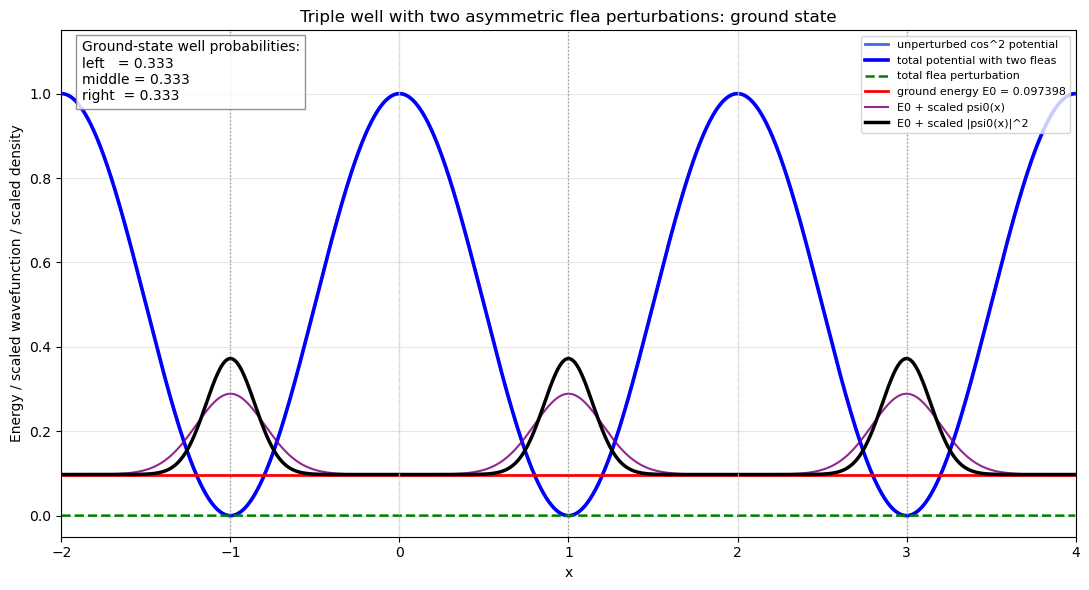

In [1]:
# ============================================================
# Triple-well Schrödinger eigenfunction simulation
# with two asymmetric flea perturbations.
#
# Potential:
#     V(x) = V_b * cos^2(pi*x/(2*a)) + flea_1(x) + flea_2(x)
#
# Compact periodic interval contains 3 minima.
#
# Computes and plots only the lowest energy eigenfunction.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# ============================================================
# 1. USER SETTINGS
# ============================================================

# Physical parameters
HBAR = 0.09
MASS = 1.0

# Cos^2 potential parameters
A = 1.0
V_BARRIER = 1.0

# Number of wells
N_WELLS = 3

# Compact periodic interval.
# This interval has length 6a and contains minima at:
# x = -a, x = a, x = 3a.
X_MIN = -2.0 * A
X_MAX = X_MIN + 2.0 * A * N_WELLS

# Grid settings
GRID_POINTS = 2400

# Number of eigenstates to compute internally.
# We compute a few for numerical stability, but plot only state 0.
N_EIGS = 4

# Plot scaling
DENSITY_SCALE = 0.30
WAVEFUNCTION_SCALE = 0.20

# Save figure?
SAVE_FIGURE = False
FIGURE_NAME = "triple_well_two_fleas_ground_state.png"


# ============================================================
# 2. FLEA SETTINGS
# ============================================================
#
# The three minima are located at:
#   left well:   x = -A
#   middle well: x =  A
#   right well:  x =  3A
#
# Below we place positive flea bumps in the left and middle wells.
# This should encourage the ground state to localize in the right well.
#
# To test other cases:
#   - Move fleas to different wells.
#   - Change flea heights.
#   - Make HBAR smaller.
# ============================================================

USE_FLEAS = False

FLEAS = [
    {
        "center": -1.10 * A,     # near left well
        "half_width": 0.18 * A,
        "height": 0.055,
        "label": "flea in left well"
    },
    {
        "center": 0.85 * A,      # near middle well, deliberately asymmetric
        "half_width": 0.13 * A,
        "height": 0.075,
        "label": "flea in middle well"
    }
]


# ============================================================
# 3. POTENTIAL FUNCTIONS
# ============================================================

def cos_squared_potential(x, a=A, v_barrier=V_BARRIER):
    """
    Heugten-Wolters style periodic multiwell potential:

        V(x) = V_b cos^2(pi x / (2a))

    The minima occur at odd multiples of a.
    """
    return v_barrier * np.cos(np.pi * x / (2.0 * a))**2


def smooth_flea_bump(x, center, half_width, height):
    """
    Smooth compactly supported bump function.

    Nonzero only for:

        |x - center| < half_width

    Formula:

        height * exp(1/c^2 - 1/(c^2 - (x-b)^2))

    where b is the center and c is the half-width.
    """
    b = center
    c = half_width
    d = height

    bump = np.zeros_like(x)
    mask = np.abs(x - b) < c

    bump[mask] = d * np.exp(
        1.0 / c**2 - 1.0 / (c**2 - (x[mask] - b)**2)
    )

    return bump


def all_fleas(x):
    """
    Sum all flea perturbations.
    """
    total = np.zeros_like(x)

    if USE_FLEAS:
        for flea in FLEAS:
            total += smooth_flea_bump(
                x,
                center=flea["center"],
                half_width=flea["half_width"],
                height=flea["height"]
            )

    return total


def total_potential(x):
    """
    Total potential:

        V_total = V_cos^2 + flea_1 + flea_2
    """
    V0 = cos_squared_potential(x)
    Vf = all_fleas(x)
    return V0 + Vf


# ============================================================
# 4. PERIODIC GRID
# ============================================================

def make_periodic_grid(x_min=X_MIN, x_max=X_MAX, n=GRID_POINTS):
    """
    Periodic grid on [x_min, x_max).

    The endpoint x_max is not included because it is identified
    with x_min under periodic boundary conditions.
    """
    length = x_max - x_min
    dx = length / n
    x = x_min + dx * np.arange(n)
    return x, dx, length


# ============================================================
# 5. PERIODIC SECOND-DERIVATIVE MATRIX
# ============================================================

def periodic_second_derivative_matrix(n, dx):
    """
    Central finite-difference second derivative with periodic
    boundary conditions.

    The finite-difference formula is:

        psi''(x_i) ≈ (psi_{i+1} - 2 psi_i + psi_{i-1}) / dx^2
    """
    main_diag = -2.0 * np.ones(n)
    off_diag = np.ones(n - 1)

    D2 = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil"
    )

    # Periodic wrap-around terms
    D2[0, n - 1] = 1.0
    D2[n - 1, 0] = 1.0

    return D2.tocsc() / dx**2


# ============================================================
# 6. BUILD HAMILTONIAN
# ============================================================

def build_hamiltonian():
    """
    Build sparse Hamiltonian matrix:

        H = -(hbar^2 / 2m) D2 + V(x)

    with periodic boundary conditions.
    """
    x, dx, length = make_periodic_grid()

    V0 = cos_squared_potential(x)
    Vf = all_fleas(x)
    V = V0 + Vf

    n = len(x)
    D2 = periodic_second_derivative_matrix(n, dx)

    kinetic = -(HBAR**2 / (2.0 * MASS)) * D2
    potential = diags(V, 0, format="csc")

    H = kinetic + potential

    return x, dx, length, V0, Vf, V, H


# ============================================================
# 7. NORMALIZATION
# ============================================================

def normalize_wavefunctions(x, psi_matrix):
    """
    Normalize eigenvectors so that:

        integral |psi(x)|^2 dx = 1
    """
    dx = x[1] - x[0]
    psi_normed = psi_matrix.copy()

    for j in range(psi_normed.shape[1]):
        norm = np.sqrt(np.sum(np.abs(psi_normed[:, j])**2) * dx)
        psi_normed[:, j] = psi_normed[:, j] / norm

        # Fix arbitrary sign for nicer plotting
        max_index = np.argmax(np.abs(psi_normed[:, j]))
        if np.real(psi_normed[max_index, j]) < 0:
            psi_normed[:, j] *= -1

    return psi_normed


# ============================================================
# 8. SOLVE EIGENVALUE PROBLEM
# ============================================================

def solve_eigenproblem():
    """
    Compute low-energy eigenvalues and eigenvectors.
    """
    x, dx, length, V0, Vf, V, H = build_hamiltonian()

    E, psi = eigsh(
        H,
        k=N_EIGS,
        which="SA",
        tol=1e-11,
        maxiter=400000
    )

    idx = np.argsort(E)
    E = E[idx]
    psi = psi[:, idx]

    psi = normalize_wavefunctions(x, psi)

    return x, dx, length, V0, Vf, V, E, psi


# ============================================================
# 9. WELL PROBABILITIES
# ============================================================

def well_masks(x, a=A):
    """
    Define three well regions on [-2a, 4a):

        left well:   [-2a, 0)
        middle well: [0, 2a)
        right well:  [2a, 4a)

    These are separated by barriers at:

        x = -2a, 0, 2a, 4a
    """
    left = (x >= -2.0 * a) & (x < 0.0)
    middle = (x >= 0.0) & (x < 2.0 * a)
    right = (x >= 2.0 * a) & (x < 4.0 * a)

    return [left, middle, right]


def probabilities_in_wells(x, psi):
    """
    Compute probability in each well region.
    """
    dx = x[1] - x[0]
    masks = well_masks(x)

    probs = []
    for mask in masks:
        probs.append(np.sum(np.abs(psi[mask])**2) * dx)

    return np.array(probs)


# ============================================================
# 10. RUN SIMULATION
# ============================================================

x, dx, length, V0, Vf, V, E, psi_matrix = solve_eigenproblem()

psi0 = psi_matrix[:, 0]
density0 = np.abs(psi0)**2
probs = probabilities_in_wells(x, psi0)

print("Simulation settings")
print("-------------------")
print(f"hbar = {HBAR}")
print(f"mass = {MASS}")
print(f"a = {A}")
print(f"V_barrier = {V_BARRIER}")
print(f"interval = [{X_MIN}, {X_MAX})")
print(f"periodic length = {length}")
print(f"grid points = {GRID_POINTS}")
print(f"dx = {dx:.6e}")

print()
print("Flea perturbations")
print("------------------")
if USE_FLEAS:
    for i, flea in enumerate(FLEAS):
        print(
            f"flea {i+1}: center = {flea['center']:.4f}, "
            f"half_width = {flea['half_width']:.4f}, "
            f"height = {flea['height']:.4f}, "
            f"{flea['label']}"
        )
else:
    print("No fleas enabled.")

print()
print("Lowest eigenvalues")
print("------------------")
for n in range(N_EIGS):
    print(f"state {n}: E = {E[n]:.12f}")

print()
print("Ground-state probability in each well")
print("-------------------------------------")
print(f"P_left   = {probs[0]:.8f}")
print(f"P_middle = {probs[1]:.8f}")
print(f"P_right  = {probs[2]:.8f}")
print(f"sum      = {probs.sum():.8f}")


# ============================================================
# 11. PLOT ONLY LOWEST ENERGY EIGENFUNCTION
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

# Plot base potential
ax.plot(
    x,
    V0,
    color="royalblue",
    lw=2.0,
    label="unperturbed cos^2 potential"
)

# Plot total potential
ax.plot(
    x,
    V,
    color="blue",
    lw=2.6,
    label="total potential with two fleas"
)

# Plot total flea contribution
ax.plot(
    x,
    Vf,
    color="green",
    lw=1.8,
    ls="--",
    label="total flea perturbation"
)

# Plot individual fleas
if USE_FLEAS:
    for i, flea in enumerate(FLEAS):
        bump = smooth_flea_bump(
            x,
            center=flea["center"],
            half_width=flea["half_width"],
            height=flea["height"]
        )
        ax.plot(
            x,
            bump,
            lw=1.2,
            ls=":",
            label=f"flea {i+1}"
        )

# Ground-state energy line
ax.axhline(
    E[0],
    color="red",
    lw=2.0,
    label=f"ground energy E0 = {E[0]:.6f}"
)

# Plot scaled ground-state wavefunction
ax.plot(
    x,
    E[0] + WAVEFUNCTION_SCALE * psi0,
    color="purple",
    lw=1.5,
    alpha=0.85,
    label="E0 + scaled psi0(x)"
)

# Plot scaled ground-state probability density
ax.plot(
    x,
    E[0] + DENSITY_SCALE * density0,
    color="black",
    lw=2.5,
    label="E0 + scaled |psi0(x)|^2"
)

# Mark minima
for xmin, label in [(-A, "left min"), (A, "middle min"), (3*A, "right min")]:
    ax.axvline(
        xmin,
        color="gray",
        lw=1.0,
        ls=":",
        alpha=0.75
    )

# Mark barriers
for xb in [-2*A, 0, 2*A, 4*A]:
    ax.axvline(
        xb,
        color="lightgray",
        lw=1.0,
        ls="--",
        alpha=0.7
    )

ax.set_title(
    "Triple well with two asymmetric flea perturbations: ground state"
)
ax.set_xlabel("x")
ax.set_ylabel("Energy / scaled wavefunction / scaled density")
ax.set_xlim(X_MIN, X_MAX)

upper_y = max(V.max() + 0.15, E[0] + DENSITY_SCALE * density0.max() + 0.15)
ax.set_ylim(-0.05, upper_y)

ax.grid(alpha=0.3)
ax.legend(fontsize=8, loc="upper right")

# Add probability annotation
text = (
    f"Ground-state well probabilities:\n"
    f"left   = {probs[0]:.3f}\n"
    f"middle = {probs[1]:.3f}\n"
    f"right  = {probs[2]:.3f}"
)

ax.text(
    0.02,
    0.98,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

plt.tight_layout()

if SAVE_FIGURE:
    plt.savefig(FIGURE_NAME, dpi=220)
    print(f"Saved figure as {FIGURE_NAME}")

plt.show()

Running open-system triple-well simulations

hbar = 0.2
------------------------------------------------------------
Unperturbed low eigenvalues:
  H0 state 0: E = 0.2087304085
  H0 state 1: E = 0.2090814979
  H0 state 2: E = 0.2090814979
  H0 state 3: E = 0.5925277009
  H0 state 4: E = 0.5925277009
  H0 state 5: E = 0.6013074443
  H0 state 6: E = 0.8692808195
  H0 state 7: E = 0.9240525513
Flea Hamiltonian low eigenvalues:
  HF state 0: E = 0.2089568644
  HF state 1: E = 0.2120791527
  HF state 2: E = 0.2138911312
  HF state 3: E = 0.5928332306
  HF state 4: E = 0.5936027003
  HF state 5: E = 0.6020938453
  HF state 6: E = 0.8697362515
  HF state 7: E = 0.9243133076

Initial-state projection norm in final basis = 0.99999986
Final flea ground-state well probabilities:
  final P_well_1 = 0.00066385
  final P_well_2 = 0.00156359
  final P_well_3 = 0.99777257
Target localization well = well 3

First crossing P_target >= 0.9: 25.094549499443826
Persistent P_target >= 0.9:   25.094549499443

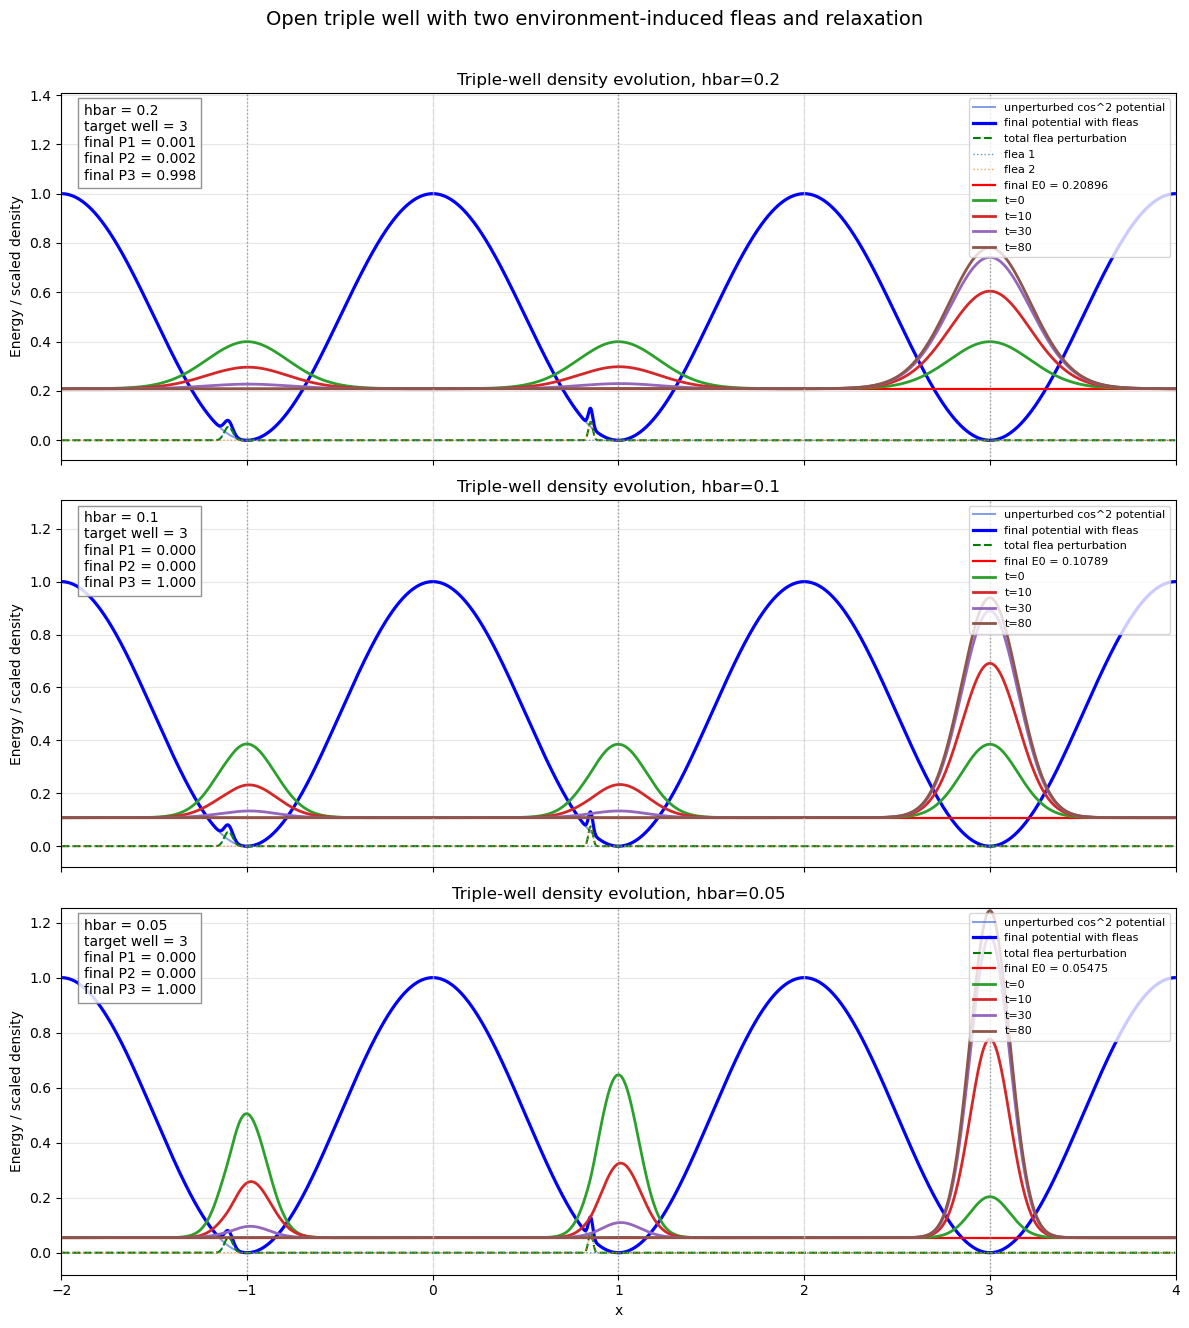

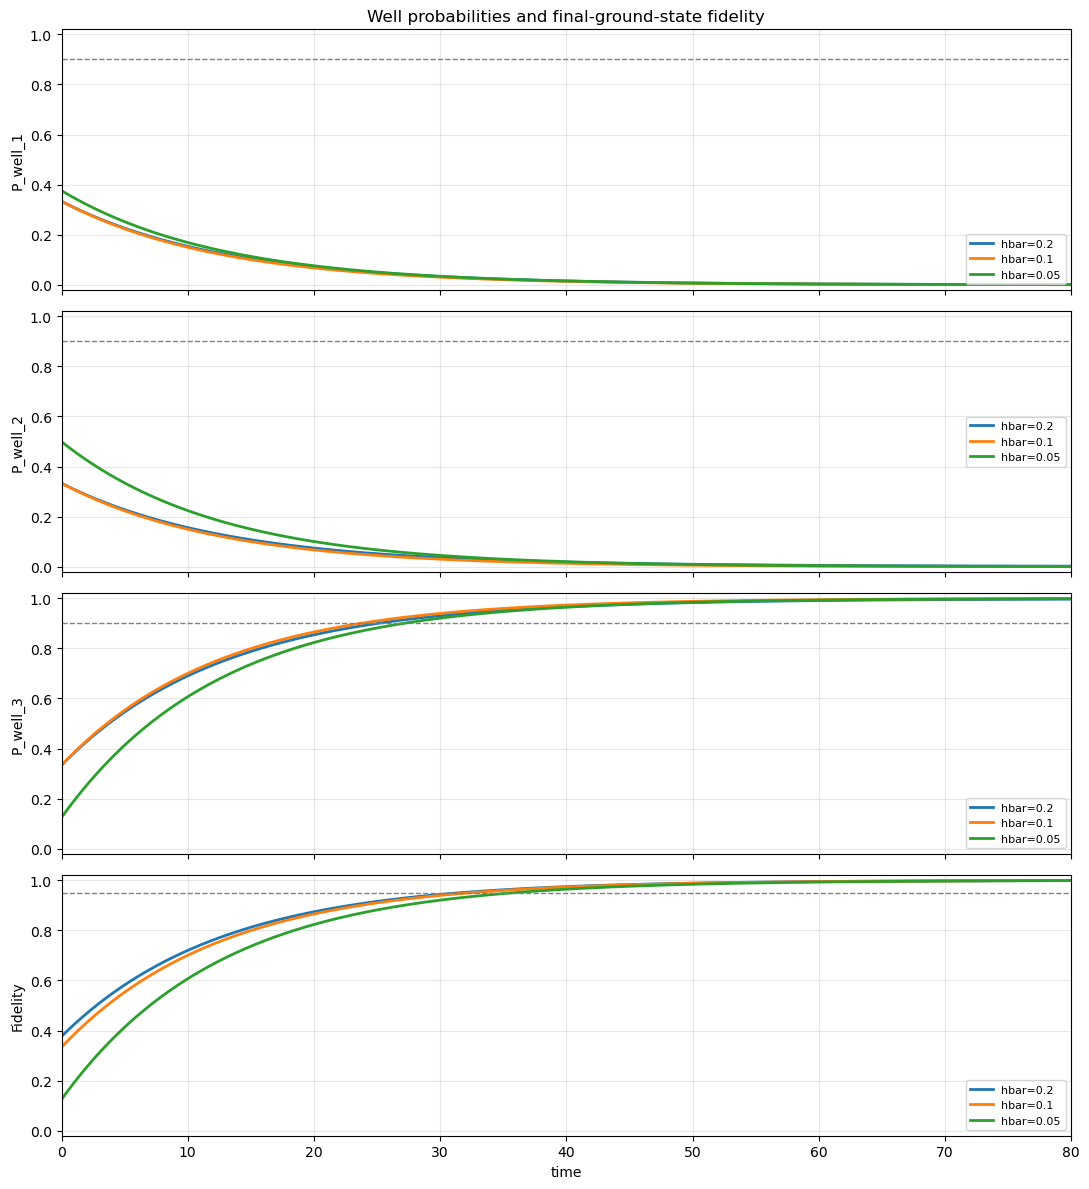

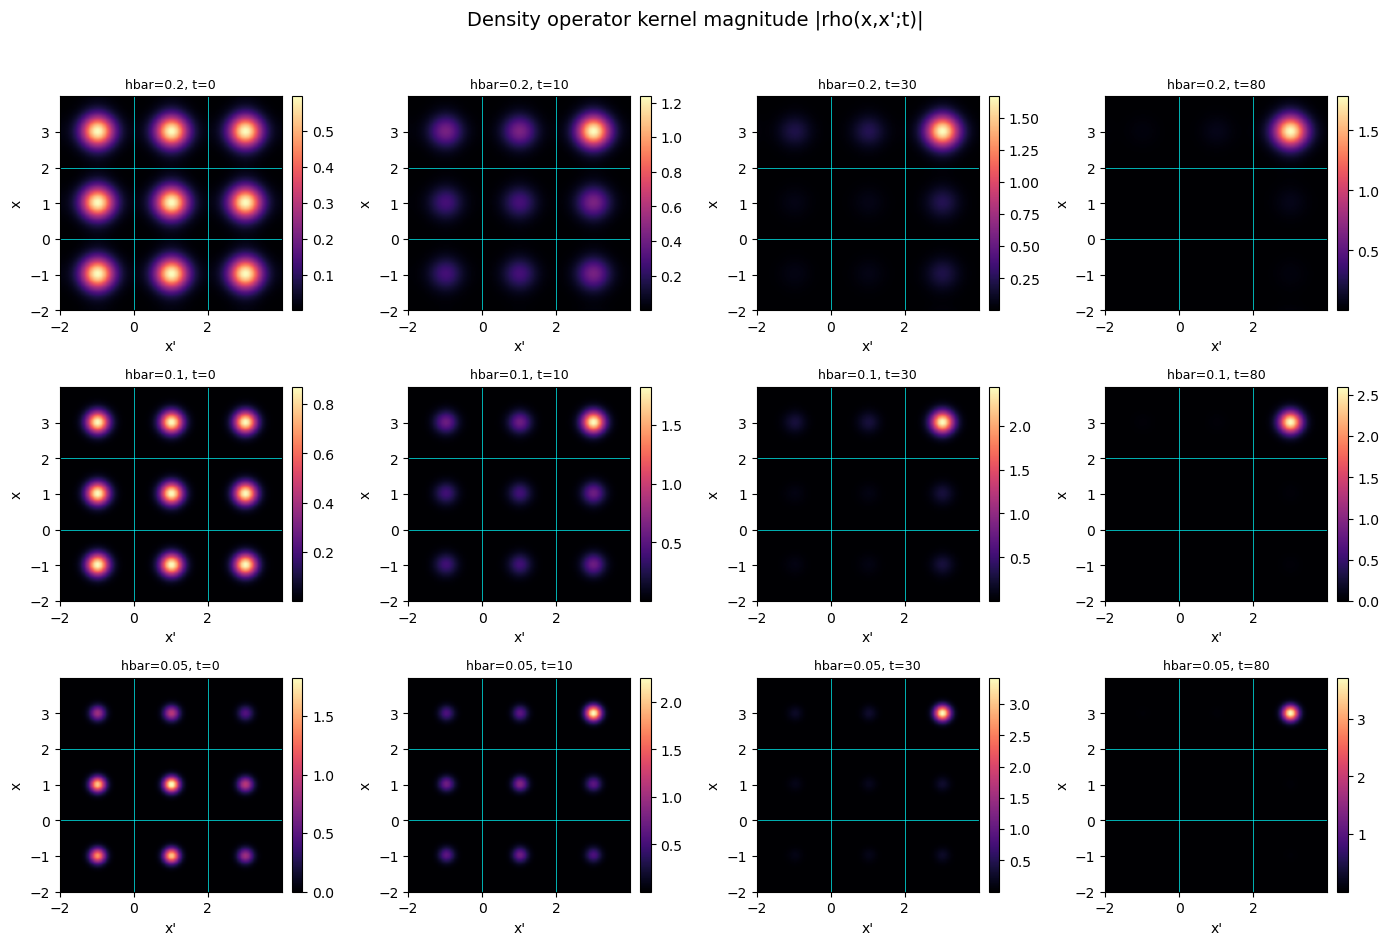


Summary

hbar = 0.2
target well = 3
final well probabilities = [6.63846576e-04 1.56358774e-03 9.97772566e-01]
projection norm = 1.000000
t_loc_first      = 25.094549499443826
t_loc_persistent = 25.094549499443826
t_fid_first      = 31.590656284760847
t_fid_persistent = 31.590656284760847

hbar = 0.1
target well = 3
final well probabilities = [3.17866957e-09 3.12243586e-09 9.99999994e-01]
projection norm = 0.999998
t_loc_first      = 23.759733036707452
t_loc_persistent = 23.759733036707452
t_fid_first      = 32.39154616240267
t_fid_persistent = 32.39154616240267

hbar = 0.05
target well = 3
final well probabilities = [3.36819982e-17 3.22906023e-17 1.00000000e+00]
projection norm = 0.999984
t_loc_first      = 27.1412680756396
t_loc_persistent = 27.1412680756396
t_fid_first      = 35.862068965517246
t_fid_persistent = 35.862068965517246


In [2]:
# ============================================================
# Open-system triple-well simulation:
# instantaneous two-flea perturbation + relaxation dynamics
#
# Base potential:
#
#   V0(x) = V_b cos^2(pi x / (2a))
#
# Periodic interval:
#
#   x in [-2a, 4a)
#
# Three minima:
#
#   x = -a, a, 3a
#
# Fleas:
#
#   Two positive asymmetric bumps in two wells.
#
# Master equation:
#
#   d rho / dt = -i/hbar [H_F, rho]
#                + sum_n gamma_n (L_n rho L_n^dagger
#                - 1/2 {L_n^dagger L_n, rho})
#
# with:
#
#   L_n = |phi_0^F><phi_n^F|, n > 0
#
# The solution is computed analytically in the final flea
# eigenbasis.
# ============================================================


import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import diags
from scipy.sparse.linalg import eigsh


# ============================================================
# 1. USER SETTINGS
# ============================================================

# Three hbar values
HBAR_VALUES = [0.20, 0.10, 0.05]

# Physical mass
MASS = 1.0

# Periodic cos^2 triple-well parameters
A = 1.0
V_BARRIER = 1.0
N_WELLS = 3

# Periodic interval:
# length = 2a * N_WELLS = 6a
# for A = 1:
#   interval = [-2, 4)
#   minima   = -1, 1, 3
#   barriers = -2, 0, 2, 4
X_MIN = -2.0 * A
X_MAX = X_MIN + 2.0 * A * N_WELLS

# Grid points
GRID_POINTS = 2600

# Truncated eigenbasis size for open-system dynamics
N_BASIS = 42

# Number of low eigenvalues to print
N_PRINT_EIGS = 8

# Relaxation rate
GAMMA_RELAX = 0.08

# Time settings
T_MAX = 80.0
N_TIME = 900

# Times for spatial density and density-matrix plots
PLOT_TIMES = [0.0, 10.0, 30.0, 80.0]

# Localization threshold
LOCALIZATION_THRESHOLD = 0.90

# Fidelity threshold to final flea ground state
FIDELITY_THRESHOLD = 0.95

# Plot scaling
DENSITY_SCALE = 0.32
WAVEFUNCTION_SCALE = 0.16

# Density matrix heatmaps
MAKE_DENSITY_MATRIX_HEATMAPS = True
MATRIX_PLOT_POINTS = 170

# Save figures?
SAVE_FIGURES = False


# ============================================================
# 2. FLEA SETTINGS
# ============================================================
#
# Triple-well minima:
#
#   well 1: x = -A
#   well 2: x =  A
#   well 3: x =  3A
#
# Below, positive fleas are placed in wells 1 and 2.
# Well 3 is left unperturbed, so for sufficiently small hbar
# the final ground state should localize near x = 3A.
# ============================================================

USE_FLEAS = True

FLEAS = [
    {
        "center": -1.10 * A,
        "half_width": 0.18 * A,
        "height": 0.055,
        "label": "flea in left well"
    },
    {
        "center": 0.85 * A,
        "half_width": 0.13 * A,
        "height": 0.075,
        "label": "flea in middle well"
    }
]


# ============================================================
# 3. POTENTIAL FUNCTIONS
# ============================================================

def cos_squared_potential(x, a=A, v_barrier=V_BARRIER):
    """
    Heugten-Wolters style periodic multiwell potential:

        V0(x) = V_b cos^2(pi x / (2a))

    Minima occur at odd multiples of a.
    Barriers occur at even multiples of a.
    """
    return v_barrier * np.cos(np.pi * x / (2.0 * a))**2


def smooth_flea_bump(x, center, half_width, height):
    """
    Smooth compactly supported bump.

    Nonzero only for:

        |x - center| < half_width

    Formula:

        height * exp(1/c^2 - 1/(c^2 - (x-b)^2))
    """
    b = center
    c = half_width
    d = height

    bump = np.zeros_like(x)
    mask = np.abs(x - b) < c

    bump[mask] = d * np.exp(
        1.0 / c**2 - 1.0 / (c**2 - (x[mask] - b)**2)
    )

    return bump


def all_fleas(x):
    """
    Sum all flea perturbations.
    """
    total = np.zeros_like(x)

    if USE_FLEAS:
        for flea in FLEAS:
            total += smooth_flea_bump(
                x,
                center=flea["center"],
                half_width=flea["half_width"],
                height=flea["height"]
            )

    return total


def final_flea_potential(x):
    """
    Final potential after instantaneous flea turn-on.
    """
    return cos_squared_potential(x) + all_fleas(x)


# ============================================================
# 4. PERIODIC GRID
# ============================================================

def make_periodic_grid(x_min=X_MIN, x_max=X_MAX, n=GRID_POINTS):
    """
    Periodic grid on [x_min, x_max).

    The endpoint x_max is excluded because it is identified
    with x_min under periodic boundary conditions.
    """
    length = x_max - x_min
    dx = length / n
    x = x_min + dx * np.arange(n)
    return x, dx, length


# ============================================================
# 5. PERIODIC SECOND DERIVATIVE MATRIX
# ============================================================

def periodic_second_derivative_matrix(n, dx):
    """
    Central finite-difference second derivative with periodic
    boundary conditions:

        psi''(x_i) ≈ (psi_{i+1} - 2 psi_i + psi_{i-1}) / dx^2
    """
    main_diag = -2.0 * np.ones(n)
    off_diag = np.ones(n - 1)

    D2 = diags(
        diagonals=[off_diag, main_diag, off_diag],
        offsets=[-1, 0, 1],
        shape=(n, n),
        format="lil"
    )

    # Periodic wrap-around entries
    D2[0, n - 1] = 1.0
    D2[n - 1, 0] = 1.0

    return D2.tocsc() / dx**2


# ============================================================
# 6. BUILD HAMILTONIAN
# ============================================================

def build_hamiltonian(x, dx, hbar, potential_values):
    """
    Build sparse Hamiltonian:

        H = -(hbar^2 / 2m) D2 + V(x)

    with periodic boundary conditions.
    """
    n = len(x)

    D2 = periodic_second_derivative_matrix(n, dx)

    kinetic = -(hbar**2 / (2.0 * MASS)) * D2
    potential = diags(potential_values, 0, format="csc")

    H = kinetic + potential
    return H


# ============================================================
# 7. EIGENPROBLEM
# ============================================================

def normalize_wavefunctions(x, psi_matrix):
    """
    Normalize eigenvectors so that:

        integral |psi(x)|^2 dx = 1
    """
    dx = x[1] - x[0]
    psi = psi_matrix.copy()

    for j in range(psi.shape[1]):
        norm = np.sqrt(np.sum(np.abs(psi[:, j])**2) * dx)
        psi[:, j] = psi[:, j] / norm

        # Fix arbitrary sign for nicer plotting
        max_index = np.argmax(np.abs(psi[:, j]))
        if np.real(psi[max_index, j]) < 0:
            psi[:, j] *= -1

    return psi


def solve_low_eigenstates(H, x, k=N_BASIS):
    """
    Compute lowest k eigenvalues and eigenvectors.
    """
    E, psi = eigsh(
        H,
        k=k,
        which="SA",
        tol=1e-11,
        maxiter=600000
    )

    idx = np.argsort(E)
    E = E[idx]
    psi = psi[:, idx]

    psi = normalize_wavefunctions(x, psi)

    return E, psi


# ============================================================
# 8. MASTER EQUATION SOLUTION IN FINAL ENERGY BASIS
# ============================================================

def initial_state_in_final_basis(x, psi_initial, phi_final):
    """
    Expansion coefficients of the initial state in the final flea basis:

        c_n = <phi_n^F | psi_initial>

    Discrete inner product includes dx.
    """
    dx = x[1] - x[0]

    c = phi_final.conj().T @ psi_initial * dx
    projection_norm = np.sum(np.abs(c)**2)

    # Renormalize inside truncated basis
    if projection_norm > 0:
        c = c / np.sqrt(projection_norm)

    rho0 = np.outer(c, c.conj())

    return c, rho0, projection_norm


def relaxation_rates(E_final, gamma_base=GAMMA_RELAX):
    """
    Low-temperature relaxation:
    every excited final eigenstate decays directly to final ground state.

        L_n = sqrt(gamma_n) |0><n|, n > 0
    """
    gamma = np.zeros_like(E_final)
    gamma[1:] = gamma_base
    return gamma


def rho_energy_basis_at_time(t, E_final, c_initial, gamma, hbar):
    """
    Exact solution for Lindblad jumps:

        L_n = sqrt(gamma_n) |0><n|, n > 0

    In the final flea eigenbasis.

    For excited diagonal entries:

        rho_nn(t) = rho_nn(0) exp(-gamma_n t)

    Ground population:

        rho_00(t) = rho_00(0)
                   + sum_n>0 rho_nn(0)(1-exp(-gamma_n t))

    Coherences:

        rho_mn(t) = rho_mn(0)
                    exp[-i(E_m-E_n)t/hbar]
                    exp[-1/2(gamma_m+gamma_n)t]
    """
    c = c_initial
    dim = len(c)

    rho_initial = np.outer(c, c.conj())
    rho = np.zeros((dim, dim), dtype=complex)

    for m in range(dim):
        for n in range(dim):
            if m == 0 and n == 0:
                continue

            phase = np.exp(-1j * (E_final[m] - E_final[n]) * t / hbar)
            decay = np.exp(-0.5 * (gamma[m] + gamma[n]) * t)
            rho[m, n] = rho_initial[m, n] * phase * decay

    # Ground population receives decayed excited populations
    rho[0, 0] = rho_initial[0, 0].real

    for n in range(1, dim):
        rho[0, 0] += rho_initial[n, n].real * (1.0 - np.exp(-gamma[n] * t))

    # Numerical cleanup
    rho = 0.5 * (rho + rho.conj().T)
    rho = rho / np.trace(rho).real

    return rho


# ============================================================
# 9. WELL PROJECTORS AND OBSERVABLES
# ============================================================

def well_masks(x, a=A):
    """
    Define three well regions for interval [-2a, 4a):

        well 1: [-2a, 0)
        well 2: [0, 2a)
        well 3: [2a, 4a)
    """
    well1 = (x >= -2.0 * a) & (x < 0.0)
    well2 = (x >= 0.0) & (x < 2.0 * a)
    well3 = (x >= 2.0 * a) & (x < 4.0 * a)

    return [well1, well2, well3]


def well_projector_matrices(x, phi_final):
    """
    Matrix representations of the three well projectors
    in the final flea eigenbasis.
    """
    dx = x[1] - x[0]
    masks = well_masks(x)

    projectors = []

    for mask in masks:
        phi_region = phi_final[mask, :]
        P = phi_region.conj().T @ phi_region * dx
        projectors.append(P)

    return projectors


def probability_from_projector(P, rho):
    """
    Compute Tr(P rho) in final eigenbasis.
    """
    return np.real(np.trace(P @ rho))


def position_density(x, phi_final, rho):
    """
    Compute rho(x,x;t):

        density(x) = sum_mn phi_m(x) rho_mn phi_n^*(x)
    """
    density = np.einsum(
        "xm,mn,xn->x",
        phi_final,
        rho,
        phi_final.conj(),
        optimize=True
    )

    density = np.real(density)
    density = np.maximum(density, 0.0)

    return density


def density_matrix_kernel_downsampled(x, phi_final, rho, n_points=MATRIX_PLOT_POINTS):
    """
    Downsampled position-space density matrix kernel:

        rho(x,x') = sum_mn phi_m(x) rho_mn phi_n^*(x')
    """
    idx = np.linspace(0, len(x) - 1, n_points).astype(int)
    x_small = x[idx]
    phi_small = phi_final[idx, :]

    kernel = phi_small @ rho @ phi_small.conj().T

    return x_small, kernel


def purity(rho):
    """
    Purity Tr(rho^2).
    """
    return np.real(np.trace(rho @ rho))


def fidelity_to_final_ground(rho):
    """
    Fidelity with final flea ground state.

    In the final energy basis this is rho_00.
    """
    return np.real(rho[0, 0])


# ============================================================
# 10. LOCALIZATION TIME ESTIMATES
# ============================================================

def first_crossing(time_grid, values, threshold):
    """
    First time where values exceed threshold.
    """
    idx = np.where(values >= threshold)[0]
    if len(idx) == 0:
        return None
    return time_grid[idx[0]]


def first_persistent_crossing(time_grid, values, threshold):
    """
    First time where values stay above threshold for all later sampled times.
    """
    above = values >= threshold

    for i in range(len(time_grid)):
        if np.all(above[i:]):
            return time_grid[i]

    return None


# ============================================================
# 11. RUN ONE HBAR VALUE
# ============================================================

def run_one_hbar(hbar):
    """
    Run full open-system triple-well pipeline for one hbar.
    """
    x, dx, length = make_periodic_grid()

    V0 = cos_squared_potential(x)
    Vf = all_fleas(x)
    V_final = V0 + Vf

    H0 = build_hamiltonian(x, dx, hbar, V0)
    HF = build_hamiltonian(x, dx, hbar, V_final)

    # Unperturbed ground state
    E_unpert, psi_unpert = solve_low_eigenstates(
        H0,
        x,
        k=max(8, min(N_BASIS, 12))
    )

    psi_initial = psi_unpert[:, 0]

    # Final flea eigenbasis
    E_final, phi_final = solve_low_eigenstates(
        HF,
        x,
        k=N_BASIS
    )

    c_initial, rho_initial_final_basis, projection_norm = initial_state_in_final_basis(
        x,
        psi_initial,
        phi_final
    )

    gamma = relaxation_rates(E_final)

    well_projectors = well_projector_matrices(x, phi_final)

    # Determine target well from final flea ground state
    final_ground_rho = np.zeros((N_BASIS, N_BASIS), dtype=complex)
    final_ground_rho[0, 0] = 1.0

    final_well_probs = np.array([
        probability_from_projector(P, final_ground_rho)
        for P in well_projectors
    ])

    target_index = int(np.argmax(final_well_probs))
    target_projector = well_projectors[target_index]

    time_grid = np.linspace(0.0, T_MAX, N_TIME)

    well_prob_series = np.zeros((len(time_grid), 3))
    target_prob_series = np.zeros(len(time_grid))
    fidelity_series = np.zeros(len(time_grid))
    purity_series = np.zeros(len(time_grid))

    for i, t in enumerate(time_grid):
        rho_t = rho_energy_basis_at_time(
            t,
            E_final,
            c_initial,
            gamma,
            hbar
        )

        for w in range(3):
            well_prob_series[i, w] = probability_from_projector(
                well_projectors[w],
                rho_t
            )

        target_prob_series[i] = probability_from_projector(
            target_projector,
            rho_t
        )

        fidelity_series[i] = fidelity_to_final_ground(rho_t)
        purity_series[i] = purity(rho_t)

    t_loc_first = first_crossing(
        time_grid,
        target_prob_series,
        LOCALIZATION_THRESHOLD
    )

    t_loc_persistent = first_persistent_crossing(
        time_grid,
        target_prob_series,
        LOCALIZATION_THRESHOLD
    )

    t_fid_first = first_crossing(
        time_grid,
        fidelity_series,
        FIDELITY_THRESHOLD
    )

    t_fid_persistent = first_persistent_crossing(
        time_grid,
        fidelity_series,
        FIDELITY_THRESHOLD
    )

    return {
        "hbar": hbar,
        "x": x,
        "dx": dx,
        "length": length,
        "V0": V0,
        "Vf": Vf,
        "V_final": V_final,
        "E_unpert": E_unpert,
        "psi_initial": psi_initial,
        "E_final": E_final,
        "phi_final": phi_final,
        "c_initial": c_initial,
        "projection_norm": projection_norm,
        "gamma": gamma,
        "well_projectors": well_projectors,
        "final_well_probs": final_well_probs,
        "target_index": target_index,
        "target_projector": target_projector,
        "time_grid": time_grid,
        "well_prob_series": well_prob_series,
        "target_prob_series": target_prob_series,
        "fidelity_series": fidelity_series,
        "purity_series": purity_series,
        "t_loc_first": t_loc_first,
        "t_loc_persistent": t_loc_persistent,
        "t_fid_first": t_fid_first,
        "t_fid_persistent": t_fid_persistent
    }


# ============================================================
# 12. RUN ALL HBAR VALUES
# ============================================================

results = []

print("Running open-system triple-well simulations")
print("===========================================")

for hbar in HBAR_VALUES:
    result = run_one_hbar(hbar)
    results.append(result)

    print()
    print(f"hbar = {hbar}")
    print("-" * 60)

    print("Unperturbed low eigenvalues:")
    for n in range(min(N_PRINT_EIGS, len(result["E_unpert"]))):
        print(f"  H0 state {n}: E = {result['E_unpert'][n]:.10f}")

    print("Flea Hamiltonian low eigenvalues:")
    for n in range(min(N_PRINT_EIGS, len(result["E_final"]))):
        print(f"  HF state {n}: E = {result['E_final'][n]:.10f}")

    print()
    print(f"Initial-state projection norm in final basis = {result['projection_norm']:.8f}")

    print("Final flea ground-state well probabilities:")
    for w, p in enumerate(result["final_well_probs"], start=1):
        print(f"  final P_well_{w} = {p:.8f}")

    print(f"Target localization well = well {result['target_index'] + 1}")

    print()
    print(f"First crossing P_target >= {LOCALIZATION_THRESHOLD}: {result['t_loc_first']}")
    print(f"Persistent P_target >= {LOCALIZATION_THRESHOLD}:   {result['t_loc_persistent']}")
    print(f"First crossing fidelity >= {FIDELITY_THRESHOLD}:   {result['t_fid_first']}")
    print(f"Persistent fidelity >= {FIDELITY_THRESHOLD}:       {result['t_fid_persistent']}")

print()
print("Flea perturbations")
print("------------------")
if USE_FLEAS:
    for i, flea in enumerate(FLEAS):
        print(
            f"flea {i+1}: center = {flea['center']:.4f}, "
            f"half_width = {flea['half_width']:.4f}, "
            f"height = {flea['height']:.4f}, "
            f"{flea['label']}"
        )
else:
    print("No fleas enabled.")


# ============================================================
# 13. PLOT POSITION DENSITIES AT SELECTED TIMES
# ============================================================

fig, axes = plt.subplots(
    nrows=len(results),
    ncols=1,
    figsize=(12, 4.5 * len(results)),
    sharex=True
)

if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    hbar = result["hbar"]
    x = result["x"]
    V0 = result["V0"]
    Vf = result["Vf"]
    V_final = result["V_final"]
    E_final = result["E_final"]
    phi_final = result["phi_final"]
    c_initial = result["c_initial"]
    gamma = result["gamma"]

    ax.plot(
        x,
        V0,
        color="royalblue",
        lw=1.4,
        alpha=0.65,
        label="unperturbed cos^2 potential"
    )

    ax.plot(
        x,
        V_final,
        color="blue",
        lw=2.3,
        label="final potential with fleas"
    )

    ax.plot(
        x,
        Vf,
        color="green",
        lw=1.5,
        ls="--",
        label="total flea perturbation"
    )

    # Individual fleas
    for i, flea in enumerate(FLEAS):
        bump = smooth_flea_bump(
            x,
            center=flea["center"],
            half_width=flea["half_width"],
            height=flea["height"]
        )
        ax.plot(
            x,
            bump,
            lw=1.0,
            ls=":",
            alpha=0.75,
            label=f"flea {i+1}" if hbar == HBAR_VALUES[0] else None
        )

    ax.axhline(
        E_final[0],
        color="red",
        lw=1.6,
        label=f"final E0 = {E_final[0]:.5f}"
    )

    for t in PLOT_TIMES:
        rho_t = rho_energy_basis_at_time(
            t,
            E_final,
            c_initial,
            gamma,
            hbar
        )

        dens_t = position_density(
            x,
            phi_final,
            rho_t
        )

        ax.plot(
            x,
            E_final[0] + DENSITY_SCALE * dens_t,
            lw=2.0,
            label=f"t={t:g}"
        )

    # Well minima
    for xm in [-A, A, 3.0 * A]:
        ax.axvline(
            xm,
            color="gray",
            lw=1.0,
            ls=":",
            alpha=0.75
        )

    # Barriers
    for xb in [-2.0 * A, 0.0, 2.0 * A, 4.0 * A]:
        ax.axvline(
            xb,
            color="lightgray",
            lw=1.0,
            ls="--",
            alpha=0.65
        )

    target_well = result["target_index"] + 1
    final_probs = result["final_well_probs"]

    annotation = (
        f"hbar = {hbar}\n"
        f"target well = {target_well}\n"
        f"final P1 = {final_probs[0]:.3f}\n"
        f"final P2 = {final_probs[1]:.3f}\n"
        f"final P3 = {final_probs[2]:.3f}"
    )

    ax.text(
        0.02,
        0.97,
        annotation,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
    )

    ax.set_title(
        f"Triple-well density evolution, hbar={hbar}"
    )
    ax.set_ylabel("Energy / scaled density")
    ax.set_xlim(X_MIN, X_MAX)

    upper = max(
        V_final.max() + 0.15,
        E_final[0] + 1.2
    )
    ax.set_ylim(-0.08, upper)

    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("x")

fig.suptitle(
    "Open triple well with two environment-induced fleas and relaxation",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

if SAVE_FIGURES:
    plt.savefig("open_triple_well_density_evolution.png", dpi=220)

plt.show()


# ============================================================
# 14. PLOT WELL PROBABILITIES AND FIDELITY
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(11, 12),
    sharex=True
)

colors = ["tab:blue", "tab:orange", "tab:green"]

for result in results:
    hbar = result["hbar"]
    t = result["time_grid"]
    probs = result["well_prob_series"]

    axes[0].plot(t, probs[:, 0], lw=2, label=f"hbar={hbar}")
    axes[1].plot(t, probs[:, 1], lw=2, label=f"hbar={hbar}")
    axes[2].plot(t, probs[:, 2], lw=2, label=f"hbar={hbar}")
    axes[3].plot(t, result["fidelity_series"], lw=2, label=f"hbar={hbar}")

axes[0].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
axes[1].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
axes[2].axhline(LOCALIZATION_THRESHOLD, color="gray", ls="--", lw=1)
axes[3].axhline(FIDELITY_THRESHOLD, color="gray", ls="--", lw=1)

axes[0].set_ylabel("P_well_1")
axes[1].set_ylabel("P_well_2")
axes[2].set_ylabel("P_well_3")
axes[3].set_ylabel("Fidelity")
axes[3].set_xlabel("time")

axes[0].set_title("Well probabilities and final-ground-state fidelity")

for ax in axes:
    ax.set_xlim(0, T_MAX)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig("open_triple_well_localization_observables.png", dpi=220)

plt.show()


# ============================================================
# 15. DENSITY MATRIX HEATMAPS |rho(x,x';t)|
# ============================================================

if MAKE_DENSITY_MATRIX_HEATMAPS:

    n_rows = len(results)
    n_cols = len(PLOT_TIMES)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(3.5 * n_cols, 3.2 * n_rows),
        sharex=False,
        sharey=False
    )

    if n_rows == 1:
        axes = np.array([axes])

    for row, result in enumerate(results):
        hbar = result["hbar"]
        x = result["x"]
        E_final = result["E_final"]
        phi_final = result["phi_final"]
        c_initial = result["c_initial"]
        gamma = result["gamma"]

        for col, t in enumerate(PLOT_TIMES):
            ax = axes[row, col]

            rho_t = rho_energy_basis_at_time(
                t,
                E_final,
                c_initial,
                gamma,
                hbar
            )

            x_small, kernel = density_matrix_kernel_downsampled(
                x,
                phi_final,
                rho_t,
                n_points=MATRIX_PLOT_POINTS
            )

            abs_kernel = np.abs(kernel)

            im = ax.imshow(
                abs_kernel,
                extent=[x_small[0], x_small[-1], x_small[0], x_small[-1]],
                origin="lower",
                aspect="auto",
                cmap="magma"
            )

            # Barrier markers
            for xb in [0.0, 2.0 * A]:
                ax.axvline(xb, color="cyan", lw=0.7, alpha=0.7)
                ax.axhline(xb, color="cyan", lw=0.7, alpha=0.7)

            ax.set_title(f"hbar={hbar}, t={t:g}", fontsize=9)
            ax.set_xlabel("x'")
            ax.set_ylabel("x")

            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(
        "Density operator kernel magnitude |rho(x,x';t)|",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if SAVE_FIGURES:
        plt.savefig("open_triple_well_density_matrix_heatmaps.png", dpi=220)

    plt.show()


# ============================================================
# 16. SUMMARY TABLE
# ============================================================

print()
print("Summary")
print("=======")

for result in results:
    print()
    print(f"hbar = {result['hbar']}")
    print(f"target well = {result['target_index'] + 1}")
    print(f"final well probabilities = {result['final_well_probs']}")
    print(f"projection norm = {result['projection_norm']:.6f}")
    print(f"t_loc_first      = {result['t_loc_first']}")
    print(f"t_loc_persistent = {result['t_loc_persistent']}")
    print(f"t_fid_first      = {result['t_fid_first']}")
    print(f"t_fid_persistent = {result['t_fid_persistent']}")
    